# Algoritmos de Boosting: GradientBoostingClassifier

Ejercicio L8: construir y optimizar un modelo de clasificación binaria con Gradient Boosting usando buenas prácticas de evaluación.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Carga y preparación de los datos

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. División en entrenamiento y prueba (80/20)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((455, 30), (114, 30))

## 3. Modelo base de Gradient Boosting

In [4]:
base_model = GradientBoostingClassifier(random_state=42)
base_model.fit(X_train, y_train)

y_pred_base = base_model.predict(X_test)

print('=== Resultados iniciales (modelo base) ===')
print(classification_report(y_test, y_pred_base, target_names=data.target_names))

=== Resultados iniciales (modelo base) ===
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 4. Importancia de las variables

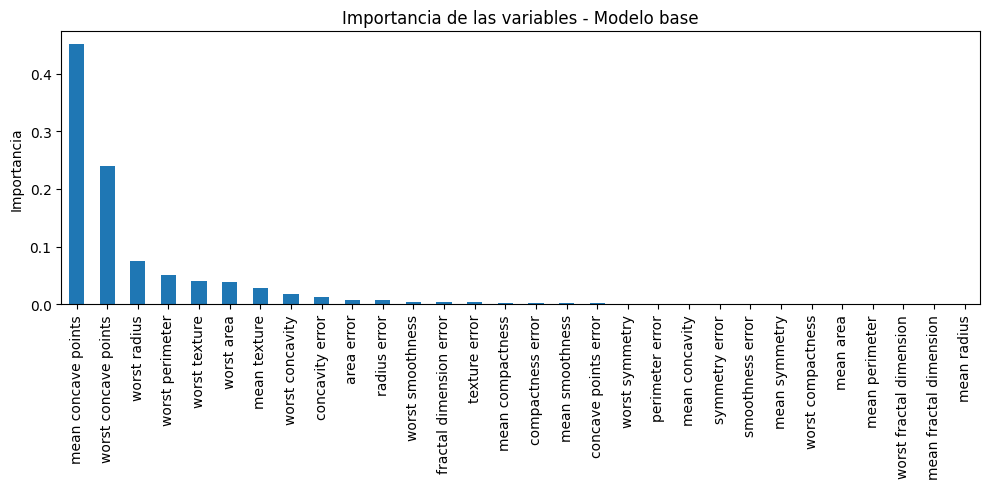

In [5]:
importances = base_model.feature_importances_
feat_imp = pd.Series(importances, index=data.feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar')
plt.title('Importancia de las variables - Modelo base')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

## 5. Búsqueda de hiperparámetros con GridSearchCV

In [6]:
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.01],
    'max_depth': [3, 4]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('Mejores parámetros encontrados:')
print(grid.best_params_)

Mejores parámetros encontrados:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


## 6. Evaluación del mejor modelo y comparación con el modelo base

In [7]:
y_pred_best = grid.predict(X_test)

print("=== Resultados tras optimización (mejor modelo) ===")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

# Comparación rápida con F1-score (clase positiva por defecto)
f1_base = f1_score(y_test, y_pred_base)
f1_best = f1_score(y_test, y_pred_best)

print(f"F1 modelo base       : {f1_base:.4f}")
print(f"F1 modelo optimizado : {f1_best:.4f}")


=== Resultados tras optimización (mejor modelo) ===
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

F1 modelo base       : 0.9650
F1 modelo optimizado : 0.9650


## 7. Resumen e ideas de mejora

En este notebook:

- Entrenamos un modelo base de Gradient Boosting y evaluamos su desempeño con métricas de clasificación.
- Analizamos la importancia de las variables para entender qué atributos influyen más en la predicción.
- Aplicamos GridSearchCV sobre `n_estimators`, `learning_rate` y `max_depth` para mejorar el modelo.
- Comparamos el modelo base con el optimizado usando F1-score en el conjunto de prueba.

Posibles mejoras adicionales:

- Probar una grilla de hiperparámetros más amplia (por ejemplo, distintas `subsample` y `max_features`).
- Incorporar validación cruzada estratificada más robusta (k-fold con más folds) y evaluar varias métricas a la vez.
- Comparar con otros modelos ensemble (Random Forest, XGBoost, LightGBM) para ver si alguno captura mejor el problema.
- Aplicar técnicas de balanceo de clases (`class_weight`, SMOTE) si el dataset estuviera más desbalanceado.
- Realizar una selección de características previa para reducir dimensionalidad y simplificar el modelo.